# **TP2 Ciencia de Datos: Clasificación de Intenciones**
**Objetivo:** Desarrollar un modelo capaz de clasificar intenciones a partir de consultas en inglés utilizando el dataset `intent.csv` (77 categorías).

## Importación de Librerías y Configuración

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import spacy
import gensim
from gensim.models import Word2Vec
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# --- Aprendizaje Automático Tradicional ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Deep Learning (PyTorch) ---
# La red neuronal (MLP) se implementa con PyTorch; sus imports están en la celda
# correspondiente de la Etapa 3 (sección 3.4).

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

## Funciones Auxiliares de Preprocesamiento de Texto

Se definen a continuación las funciones de limpieza y normalización del texto.
Se declaran aquí —junto a los imports— porque se utilizan tanto en la **Etapa 1 (EDA)**
(nube de palabras, vocabulario exclusivo) como en la **Etapa 2 (Preprocesamiento)**
(vectorización TF-IDF).

El proceso incluye:
- **Lowercase** y eliminación de caracteres especiales.
- **Tokenización** y eliminación de *stop words* en inglés.
- **Lematización** con `WordNetLemmatizer` (NLTK), respetando la categoría gramatical de cada token.

El resultado se almacena en la columna `text_clean`.

In [97]:
def clean_text(text: str) -> str:
    """
    Preprocesa texto en inglés para vectorización con TF-IDF:
      1. Lowercase
      2. Eliminación de URLs
      3. Eliminación de caracteres no alfanuméricos
      4. Tokenización
      5. POS tagging (para lemmatización precisa de verbos y sustantivos)
      6. Eliminación de stopwords y tokens cortos (< 2 chars)
      7. Lemmatización con POS (varía lemmatización dependiendo del tipo de palabra)

    NO usar con SBERT/embeddings (rompe el contexto semántico).
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    tokens = [
        _lemmatizer.lemmatize(token, pos=get_wordnet_pos(tag))
        for token, tag in pos_tags
        if token not in _stop_words and len(token) > 1
    ]
    return ' '.join(tokens)



In [98]:
_lemmatizer = WordNetLemmatizer()
_stop_words = set(stopwords.words('english'))

def get_wordnet_pos(treebank_tag: str) -> str:
    """Convierte POS tag de NLTK (Treebank) a formato WordNet para lemmatización.
    """
    if treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default: sustantivo

# Etapa 1 — Análisis Exploratorio de Datos (EDA)

En esta etapa se realiza un análisis exhaustivo del dataset **intent.csv** para
comprender su estructura, distribución y características principales.

1. **Carga y descripción del dataset:** dimensiones, tipos de datos y valores nulos.
2. **Distribución de clases:** frecuencia y balance de las 77 intenciones.
3. **Nube de palabras:** términos más frecuentes en el corpus.
4. **Análisis de longitud de los mensajes:** distribución de `word_count` y `char_count`.
5. **Correlación entre variables numéricas.**
6. **Distribución de `avg_word_length` por clase.**
7. **Vocabulario exclusivo por clase.**

El dataset se encuentra en el archivo `intent.csv` y contiene las variables:
- **`text`**: mensaje original del usuario (en inglés).
- **`category`**: intención detectada (77 categorías posibles).

In [99]:
df = pd.read_csv("./Documentos/intent.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: 13083 filas x 2 columnas

Primeras filas:


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [100]:
# Variables numéricas derivadas del texto ─────────────────────────────────
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df["char_count"] = df["text"].astype(str).apply(len)

# Texto normalizado y lematizado (usado en EDA y vectorización) ────────────
# clean_text está definida en "Funciones Auxiliares" al inicio del notebook
df_clean = pd.DataFrame({
    "text_clean": df["text"].apply(clean_text),
    "category": df["category"]
})

print("=== Estadísticas de longitud ===")
print(df[["word_count", "char_count"]].describe().round(2))
print(f"\nColumna text_clean creada: {df_clean.notna().sum()} registros procesados")


=== Estadísticas de longitud ===
       word_count  char_count
count    13083.00    13083.00
mean        11.71       58.24
std          7.64       39.56
min          2.00       13.00
25%          7.00       36.00
50%         10.00       46.00
75%         13.00       63.00
max         79.00      433.00

Columna text_clean creada: text_clean    13083
category      13083
dtype: int64 registros procesados


**Información general del dataset: tipos de datos y memoria:**

In [101]:
print("=== Información del DataFrame ===")
df.info()

print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

print(f"\n=== Filas duplicadas: {df.duplicated().sum()} ===")

=== Información del DataFrame ===
<class 'pandas.DataFrame'>
RangeIndex: 13083 entries, 0 to 13082
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        13083 non-null  str  
 1   category    13083 non-null  str  
 2   word_count  13083 non-null  int64
 3   char_count  13083 non-null  int64
dtypes: int64(2), str(2)
memory usage: 409.0 KB

=== Valores nulos por columna ===
text          0
category      0
word_count    0
char_count    0
dtype: int64

=== Filas duplicadas: 0 ===


## Distribución de Clases

Se analiza la distribución de las 77 categorías de intención:
- **Estadísticas:** cantidad mínima, máxima y promedio de muestras por clase.
- **Tabla resumen:** porcentaje de representación de cada categoría.
- **Histograma:** frecuencia de aparición de cada clase, ordenadas de mayor a menor.

In [102]:
class_counts = df["category"].value_counts()
class_pcts   = df["category"].value_counts(normalize=True).mul(100).round(2)

class_summary = pd.DataFrame({
    "Cantidad": class_counts,
    "Porcentaje (%)": class_pcts
})

print(f"Número de categorías únicas: {df['category'].nunique()}")
print(f"\nMínimo de muestras por clase : {class_counts.min()} — Clase: '{class_counts.idxmin()}'")
print(f"Máximo de muestras por clase : {class_counts.max()} — Clase: '{class_counts.idxmax()}'")
print(f"Promedio de muestras por clase: {class_counts.mean():.1f}")
print()

print("\nResumen: ")
class_summary


Número de categorías únicas: 77

Mínimo de muestras por clase : 75 — Clase: 'contactless_not_working'
Máximo de muestras por clase : 227 — Clase: 'card_payment_fee_charged'
Promedio de muestras por clase: 169.9


Resumen: 


,Cantidad,Porcentaje (%)
category,,
card_payment_fee_charged,227,1.74
direct_debit_payment_not_recognised,222,1.70
balance_not_updated_after_cheque_or_cash_deposit,221,1.69
wrong_amount_of_cash_received,220,1.68
cash_withdrawal_charge,217,1.66
...,...,...
lost_or_stolen_card,122,0.93
card_swallowed,101,0.77
card_acceptance,99,0.76


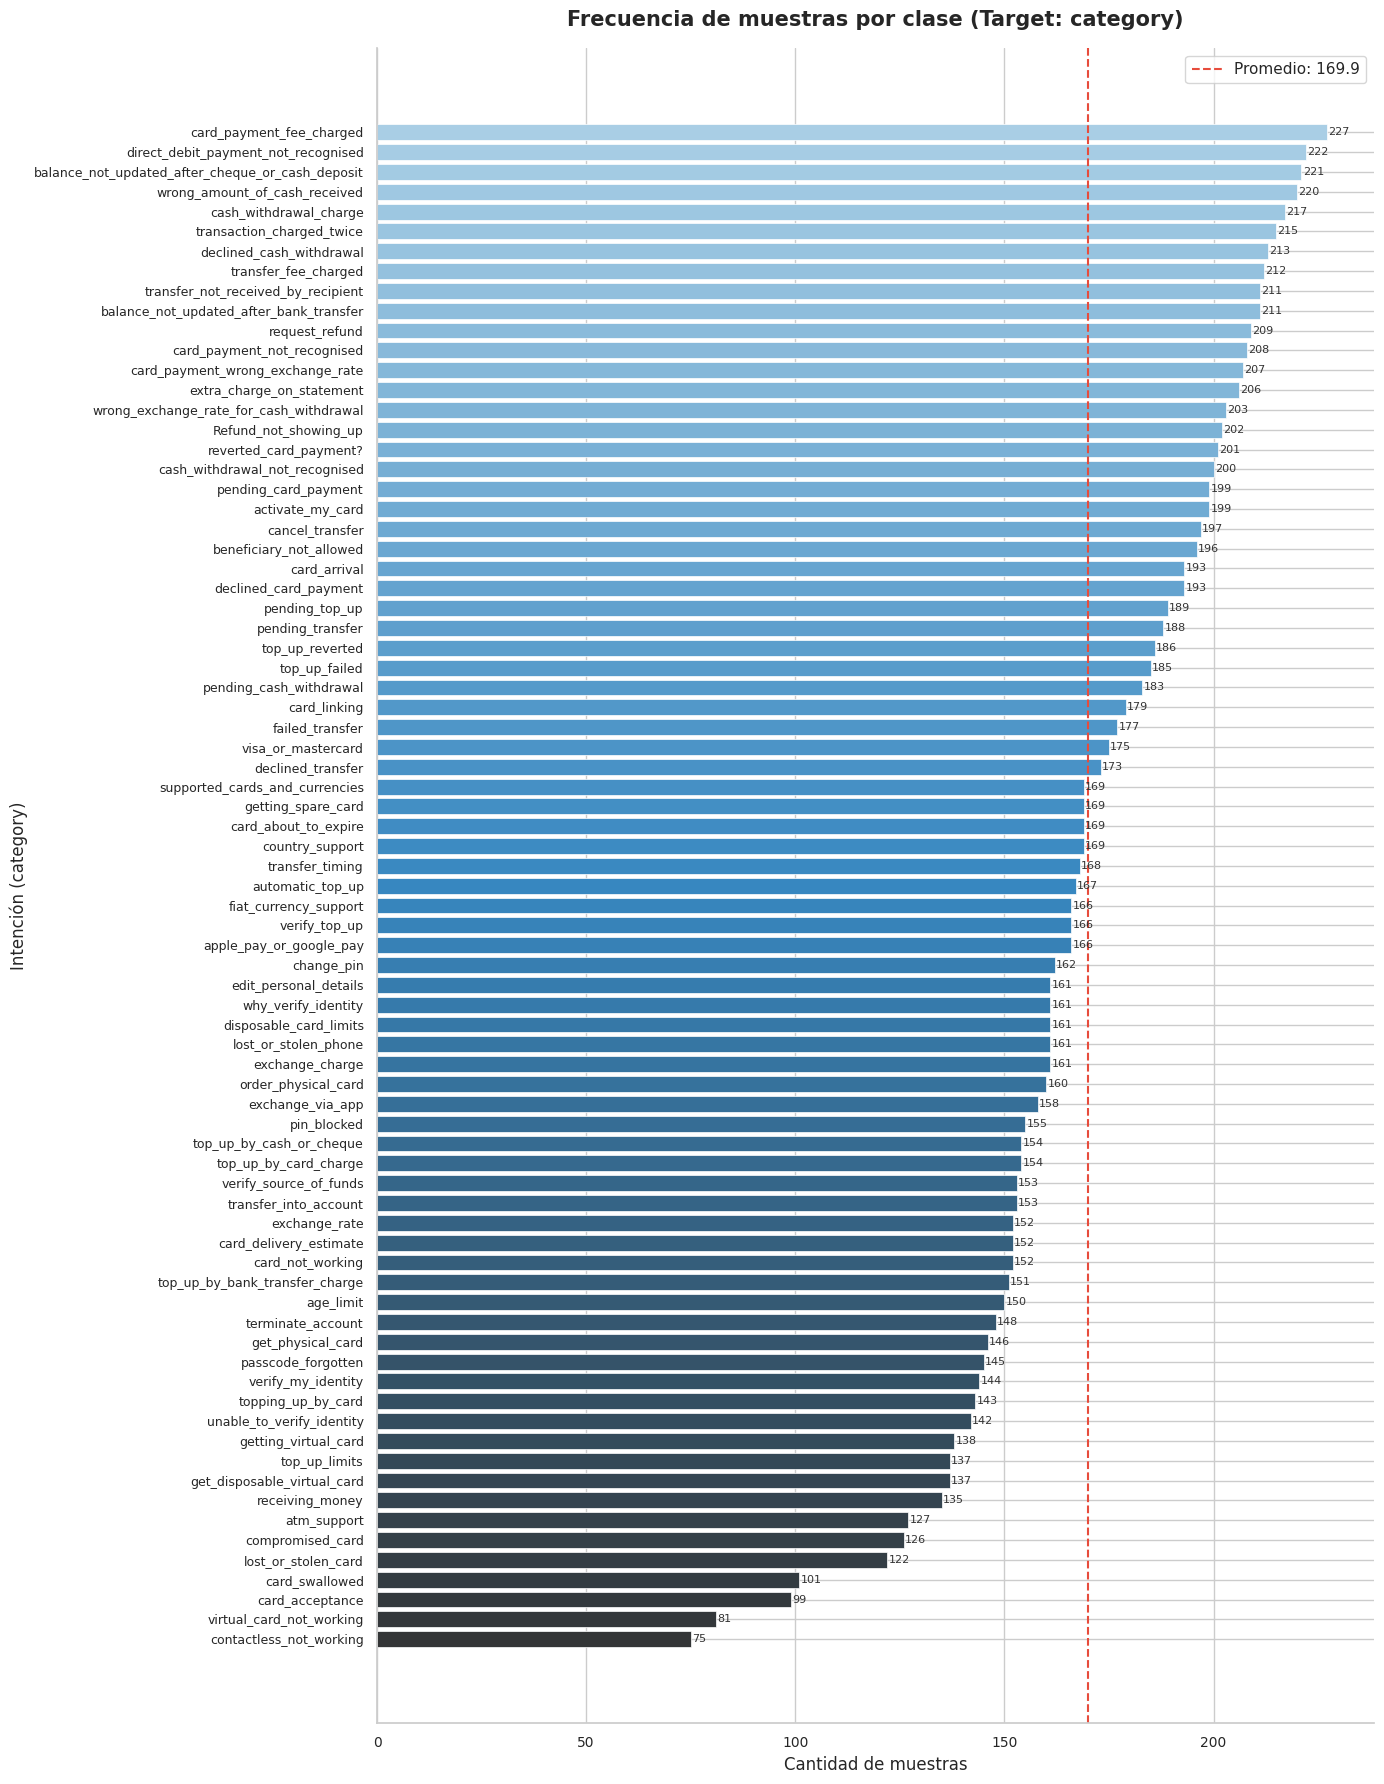

In [103]:
# Histograma de frecuencia por clase (ordenado de mayor a menor)
fig, ax = plt.subplots(figsize=(14, 18))

palette = sns.color_palette("Blues_d", n_colors=len(class_counts))

bars = ax.barh(
    class_counts.index,
    class_counts.values,
    color=palette,
    edgecolor="white",
    linewidth=0.5
)

avg = class_counts.mean()
ax.axvline(avg, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Promedio: {avg:.1f}")

for bar, count in zip(bars, class_counts.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center", ha="left",
        fontsize=8, color="#333333"
    )

ax.set_title("Frecuencia de muestras por clase (Target: category)", fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("Cantidad de muestras", fontsize=12)
ax.set_ylabel("Intención (category)", fontsize=12)
ax.invert_yaxis()   # la clase más frecuente arriba
ax.legend(fontsize=11)
ax.tick_params(axis="y", labelsize=9)
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

## Nube de Palabras del Corpus

Se genera una nube de palabras a partir del texto preprocesado (`text_clean`) de todo el corpus.

Las palabras de mayor tamaño son las más frecuentes y permiten identificar los términos dominantes en el vocabulario de las consultas.

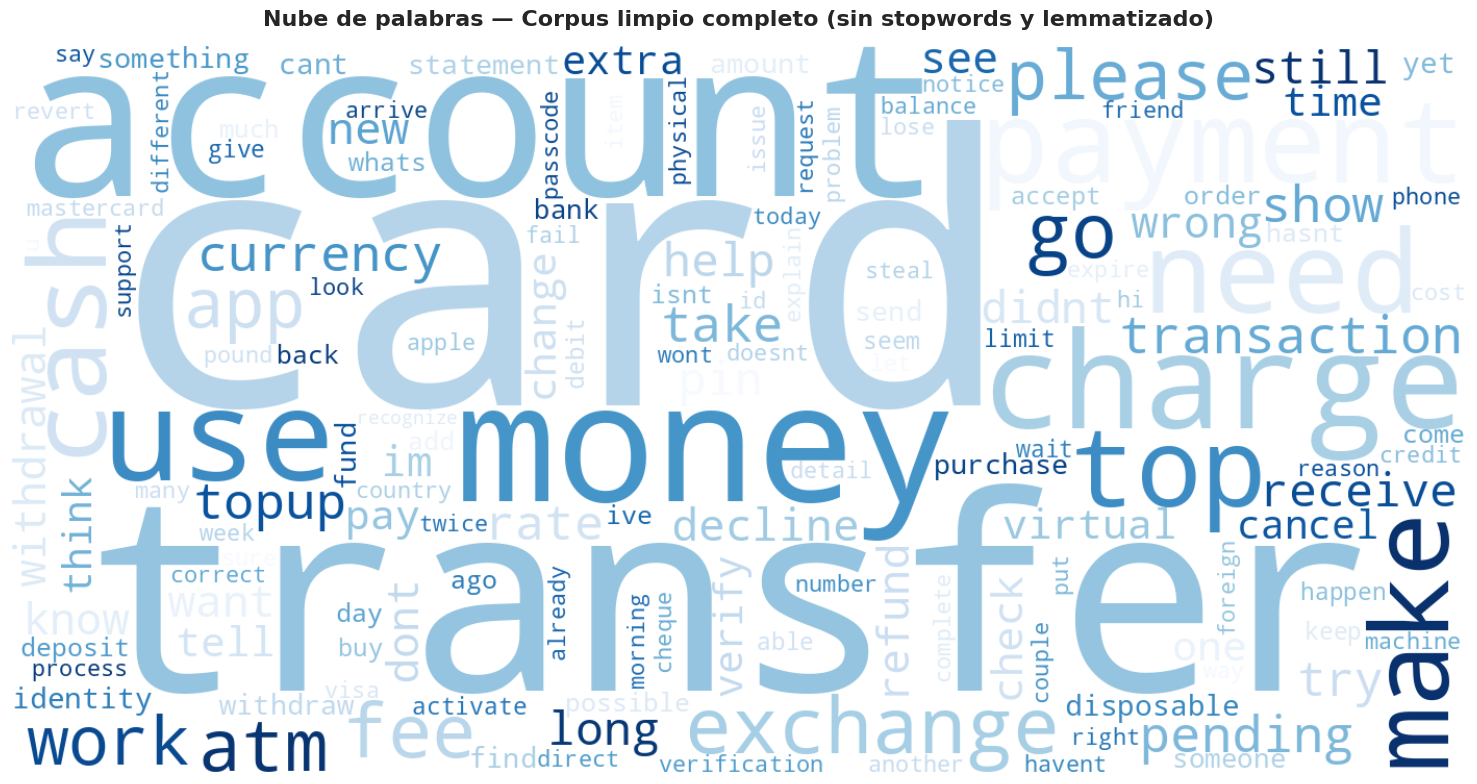

In [104]:
corpus_text = " ".join(df_clean["text_clean"].astype(str).tolist())

wc_global = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False,   # evita repetir bigramas
    contour_color="steelblue",
    contour_width=1
).generate(corpus_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc_global, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — Corpus limpio completo (sin stopwords y lemmatizado)", fontsize=16, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

## Análisis de Longitud de los Mensajes

Se calculan y visualizan las siguientes métricas derivadas de cada mensaje:
- **`word_count`**: cantidad de palabras en el texto original.
- **`char_count`**: cantidad de caracteres (sin espacios) en el texto original.

Para cada métrica se presenta:
1. **Histograma** con estadísticas descriptivas básicas.
2. **Boxplot por clase** — permite ver si ciertas intenciones tienden a expresarse con mensajes más largos o cortos.
3. **Detección de outliers** — se identifican mensajes atípicos usando el criterio 1.5 × IQR.

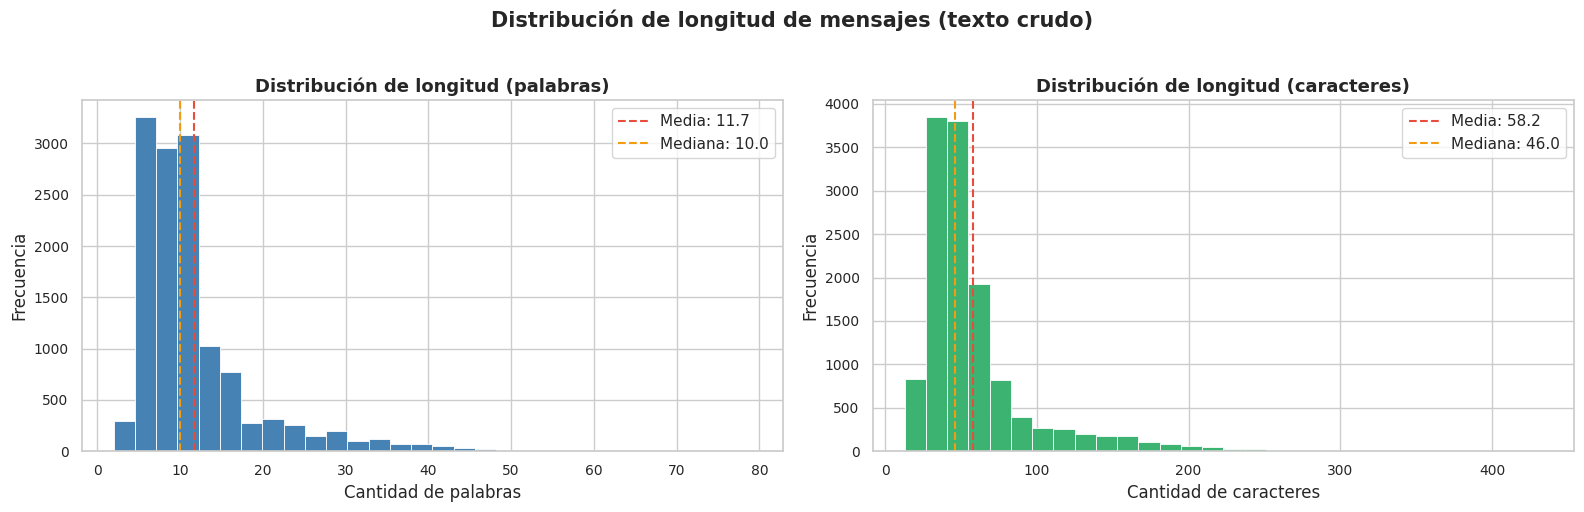

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# istribución en palabras ---
axes[0].hist(df["word_count"], bins=30, color="steelblue", edgecolor="white", linewidth=0.6)
axes[0].axvline(df["word_count"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Media: {df['word_count'].mean():.1f}")
axes[0].axvline(df["word_count"].median(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mediana: {df['word_count'].median():.1f}")
axes[0].set_title("Distribución de longitud (palabras)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Cantidad de palabras")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Distribución en caracteres ---
axes[1].hist(df["char_count"], bins=30, color="mediumseagreen", edgecolor="white", linewidth=0.6)
axes[1].axvline(df["char_count"].mean(),   color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Media: {df['char_count'].mean():.1f}")
axes[1].axvline(df["char_count"].median(), color="#f39c12", linestyle="--", linewidth=1.5, label=f"Mediana: {df['char_count'].median():.1f}")
axes[1].set_title("Distribución de longitud (caracteres)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cantidad de caracteres")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.suptitle("Distribución de longitud de mensajes (texto crudo)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


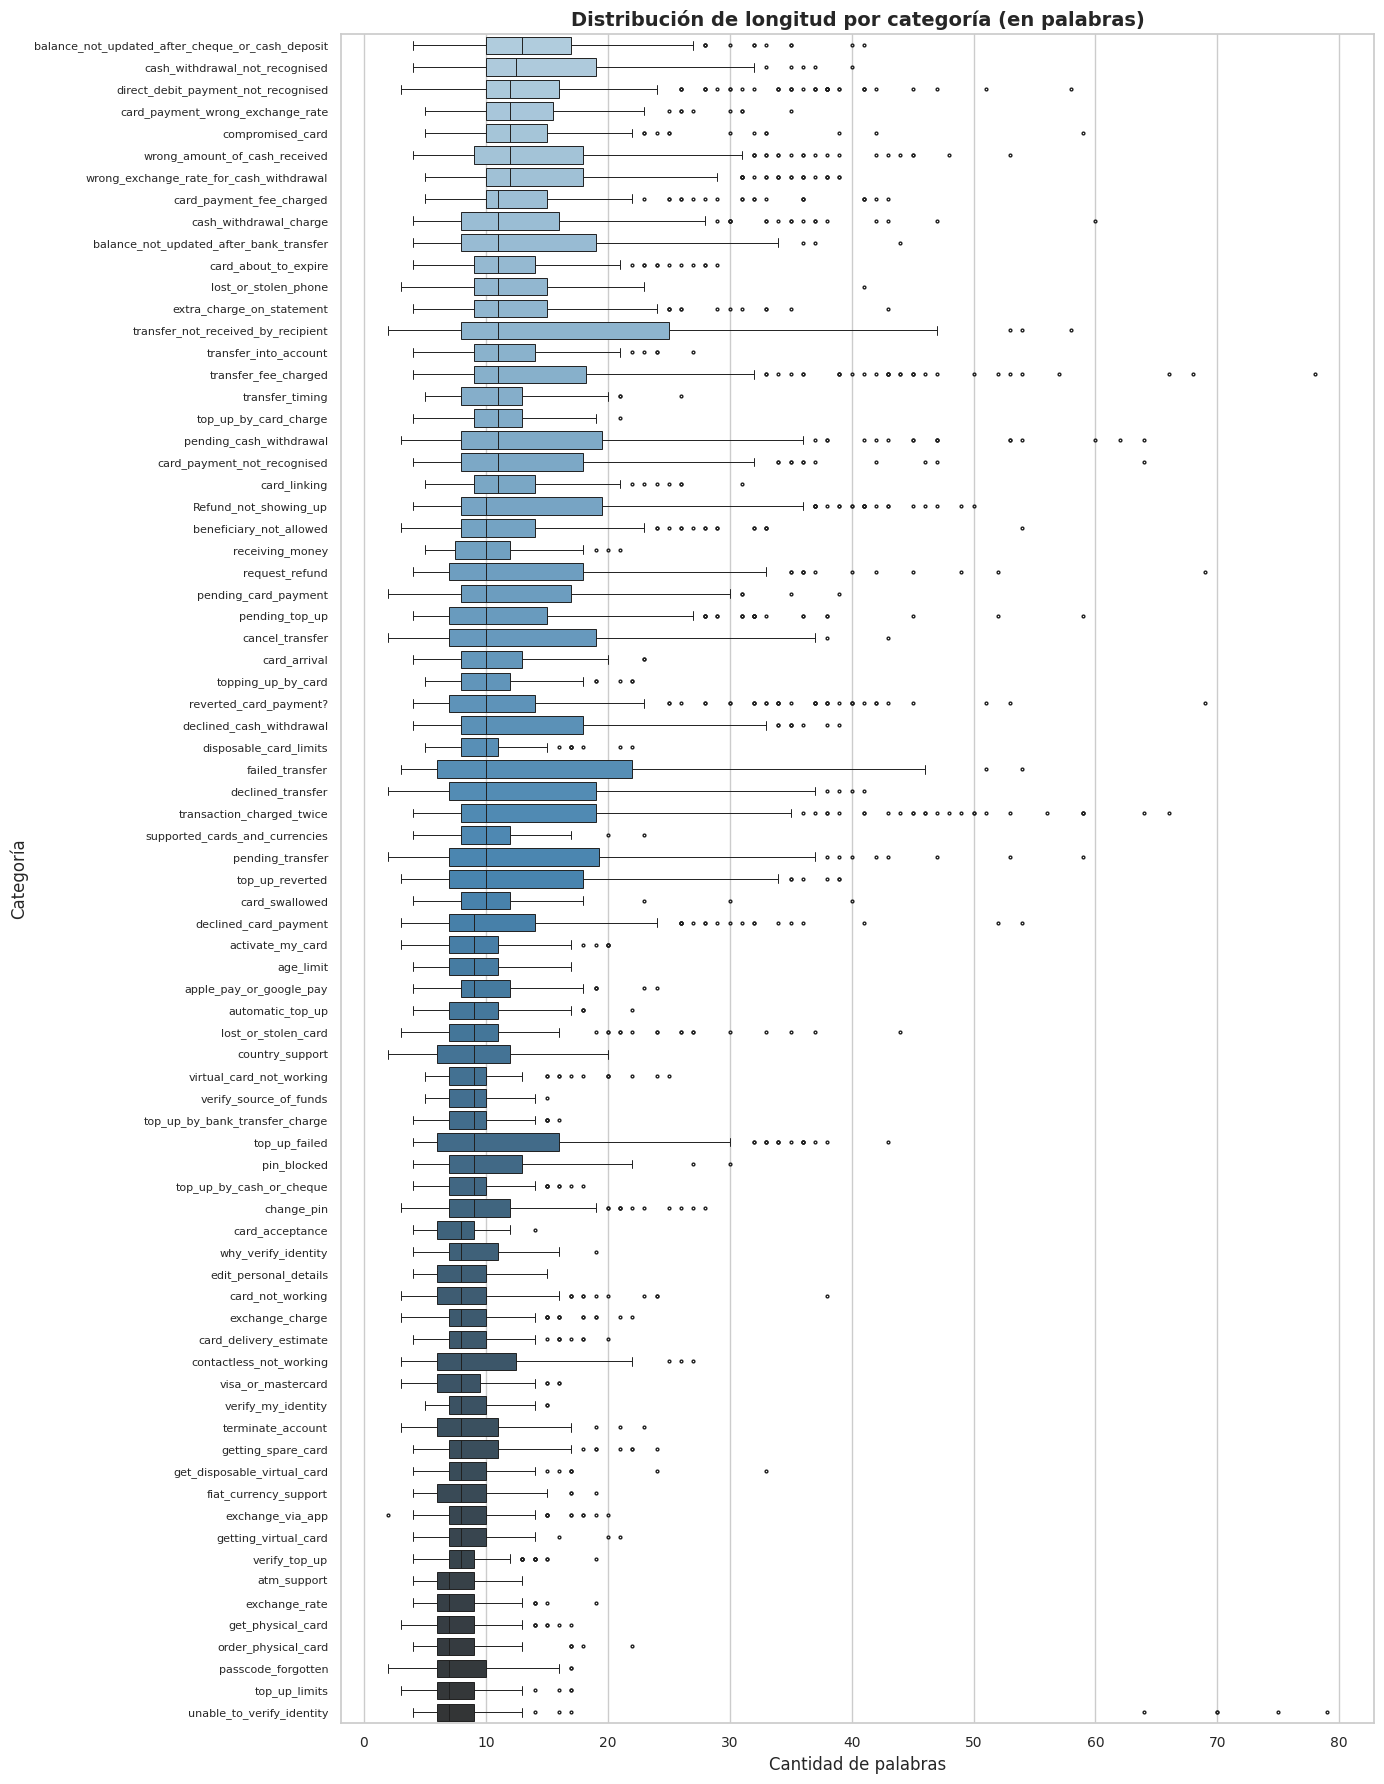

In [106]:
order = (df.groupby("category")["word_count"]
           .median()
           .sort_values(ascending=False)
           .index)

fig, ax = plt.subplots(figsize=(14, 18))
sns.boxplot(
    data=df,
    x="word_count",
    y="category",
    order=order,
    palette="Blues_d",
    linewidth=0.7,
    fliersize=2,
    ax=ax
)
ax.set_title("Distribución de longitud por categoría (en palabras)", fontsize=14, fontweight="bold")
ax.set_xlabel("Cantidad de palabras")
ax.set_ylabel("Categoría")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


In [107]:
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)
IQR = Q3 - Q1

muy_cortos = df[df["word_count"] <= 3]
muy_largos = df[df["word_count"] > Q3 + 1.5 * IQR]

print(f"Mensajes muy cortos (≤ 3 palabras): {len(muy_cortos)} ({100*len(muy_cortos)/len(df):.2f}%)")
print(f"Mensajes muy largos (> Q3 + 1.5·IQR = {Q3 + 1.5*IQR:.0f} palabras): {len(muy_largos)} ({100*len(muy_largos)/len(df):.2f}%)")

print("\nEjemplos de mensajes muy cortos")
print(muy_cortos[["text", "category", "word_count"]].head(5).to_string(index=False))

print("\nEjemplos de mensajes muy largos")
print(muy_largos[["text", "category", "word_count"]].sort_values("word_count", ascending=False).head(5).to_string(index=False))


Mensajes muy cortos (≤ 3 palabras): 49 (0.37%)
Mensajes muy largos (> Q3 + 1.5·IQR = 22 palabras): 1118 (8.55%)

Ejemplos de mensajes muy cortos
                         text                category  word_count
  withdrawal pending meaning? pending_cash_withdrawal           3
Explain pending transactions. pending_cash_withdrawal           3
           Report stolen card     lost_or_stolen_card           3
         Cancel a transaction         cancel_transfer           3
         stop the transaction         cancel_transfer           3

Ejemplos de mensajes muy largos
                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Correlación entre Variables Numéricas

Se calcula la correlación entre `word_count` y `char_count` mediante dos coeficientes:
- **Pearson** (correlación lineal).
- **Spearman** (correlación por rangos, más robusta ante outliers).

Un coeficiente cercano a 1 indica que ambas variables son altamente redundantes.

--- Correlaciones ---
Coeficiente de Pearson:  0.9840
Coeficiente de Spearman: 0.9423



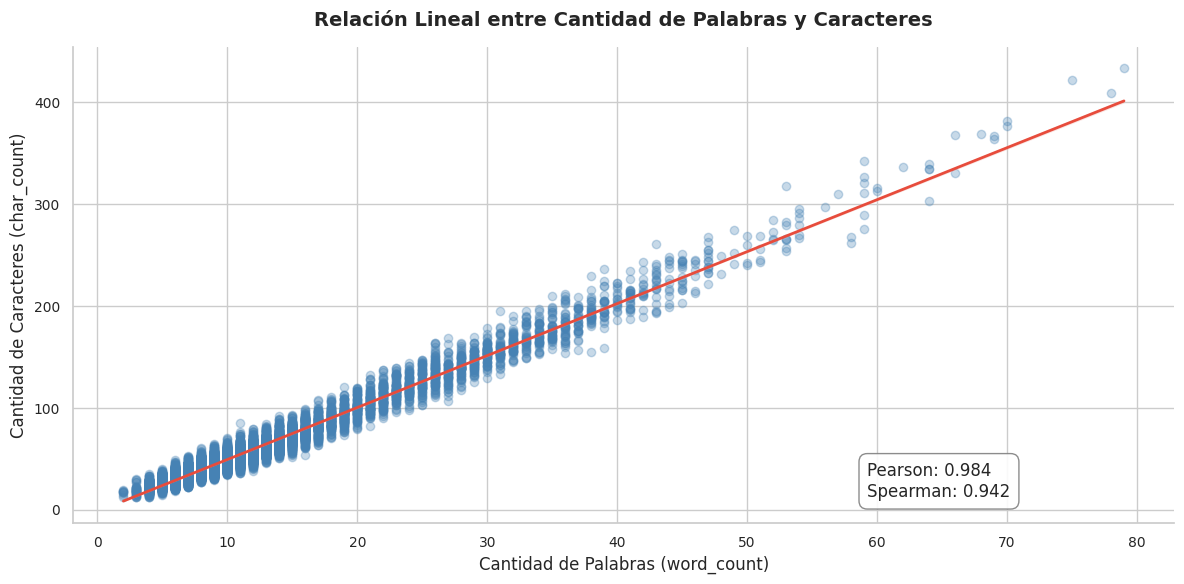

In [108]:
corr_pearson = df['word_count'].corr(df['char_count'], method='pearson')
corr_spearman = df['word_count'].corr(df['char_count'], method='spearman')

print("--- Correlaciones ---")
print(f"Coeficiente de Pearson:  {corr_pearson:.4f}")
print(f"Coeficiente de Spearman: {corr_spearman:.4f}\n")

# Gráfico de dispersión (Scatterplot) con línea de regresión
plt.figure(figsize=(12, 6))
sns.regplot(
    data=df, 
    x="word_count", 
    y="char_count", 
    scatter_kws={"alpha": 0.3, "color": "steelblue"},
    line_kws={"color": "#e74c3c", "linewidth": 2}
)

plt.title("Relación Lineal entre Cantidad de Palabras y Caracteres", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Cantidad de Palabras (word_count)", fontsize=12)
plt.ylabel("Cantidad de Caracteres (char_count)", fontsize=12)

x_pos = df['word_count'].max() * 0.75
y_pos = df['char_count'].min() or 10

plt.text(
    x=x_pos, 
    y=y_pos, 
    s=f"Pearson: {corr_pearson:.3f}\nSpearman: {corr_spearman:.3f}", 
    fontsize=12, 
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5')
)

sns.despine()
plt.tight_layout()
plt.show()

## Vocabulario Exclusivo por Clase

Se analiza qué palabras aparecen **única y exclusivamente** en las consultas de una determinada
intención (clase) y en ninguna otra. Este análisis aporta valor al EDA por dos razones principales:

1. **Discriminabilidad léxica:** cuanto mayor sea el vocabulario exclusivo de una clase, más
   fácil resulta separarla del resto. Si la mayoría de las palabras son compartidas entre clases,
   el clasificador deberá apoyarse en la distribución conjunta del vocabulario (p. ej., TF-IDF)
   antes que en términos únicos.
2. **Selección de features:** identificar los términos exclusivos de cada clase permite construir
   listas de palabras altamente informativas que pueden utilizarse como señales adicionales o para
   filtrar ruido en representaciones de bolsa de palabras.

> **Interpretación del gráfico:** se muestra, para las clases con **mayor vocabulario exclusivo**,
> cuántas palabras distintas pertenecen solamente a esa intención. Una barra alta indica que la clase
> posee terminología propia que el modelo puede aprender a explotar directamente.
> Un vocabulario exclusivo bajo —o nulo— indica que la clase comparte casi todo su léxico con otras
> intenciones, lo que aumenta la dificultad de clasificación.

Total de clases analizadas : 77
Clases CON palabras exclusivas : 77 / 77  (es decir, 77 intenciones tienen al menos 1 término único)
Clases SIN palabras exclusivas : 0 / 77  (todo su léxico es compartido con otras intenciones)
Mediana de palabras exclusivas : 12  (la mitad de las clases tiene ≤ 12 términos únicos)
Media   de palabras exclusivas : 12.9
Máximo  de palabras exclusivas : 42
Mínimo  de palabras exclusivas : 2


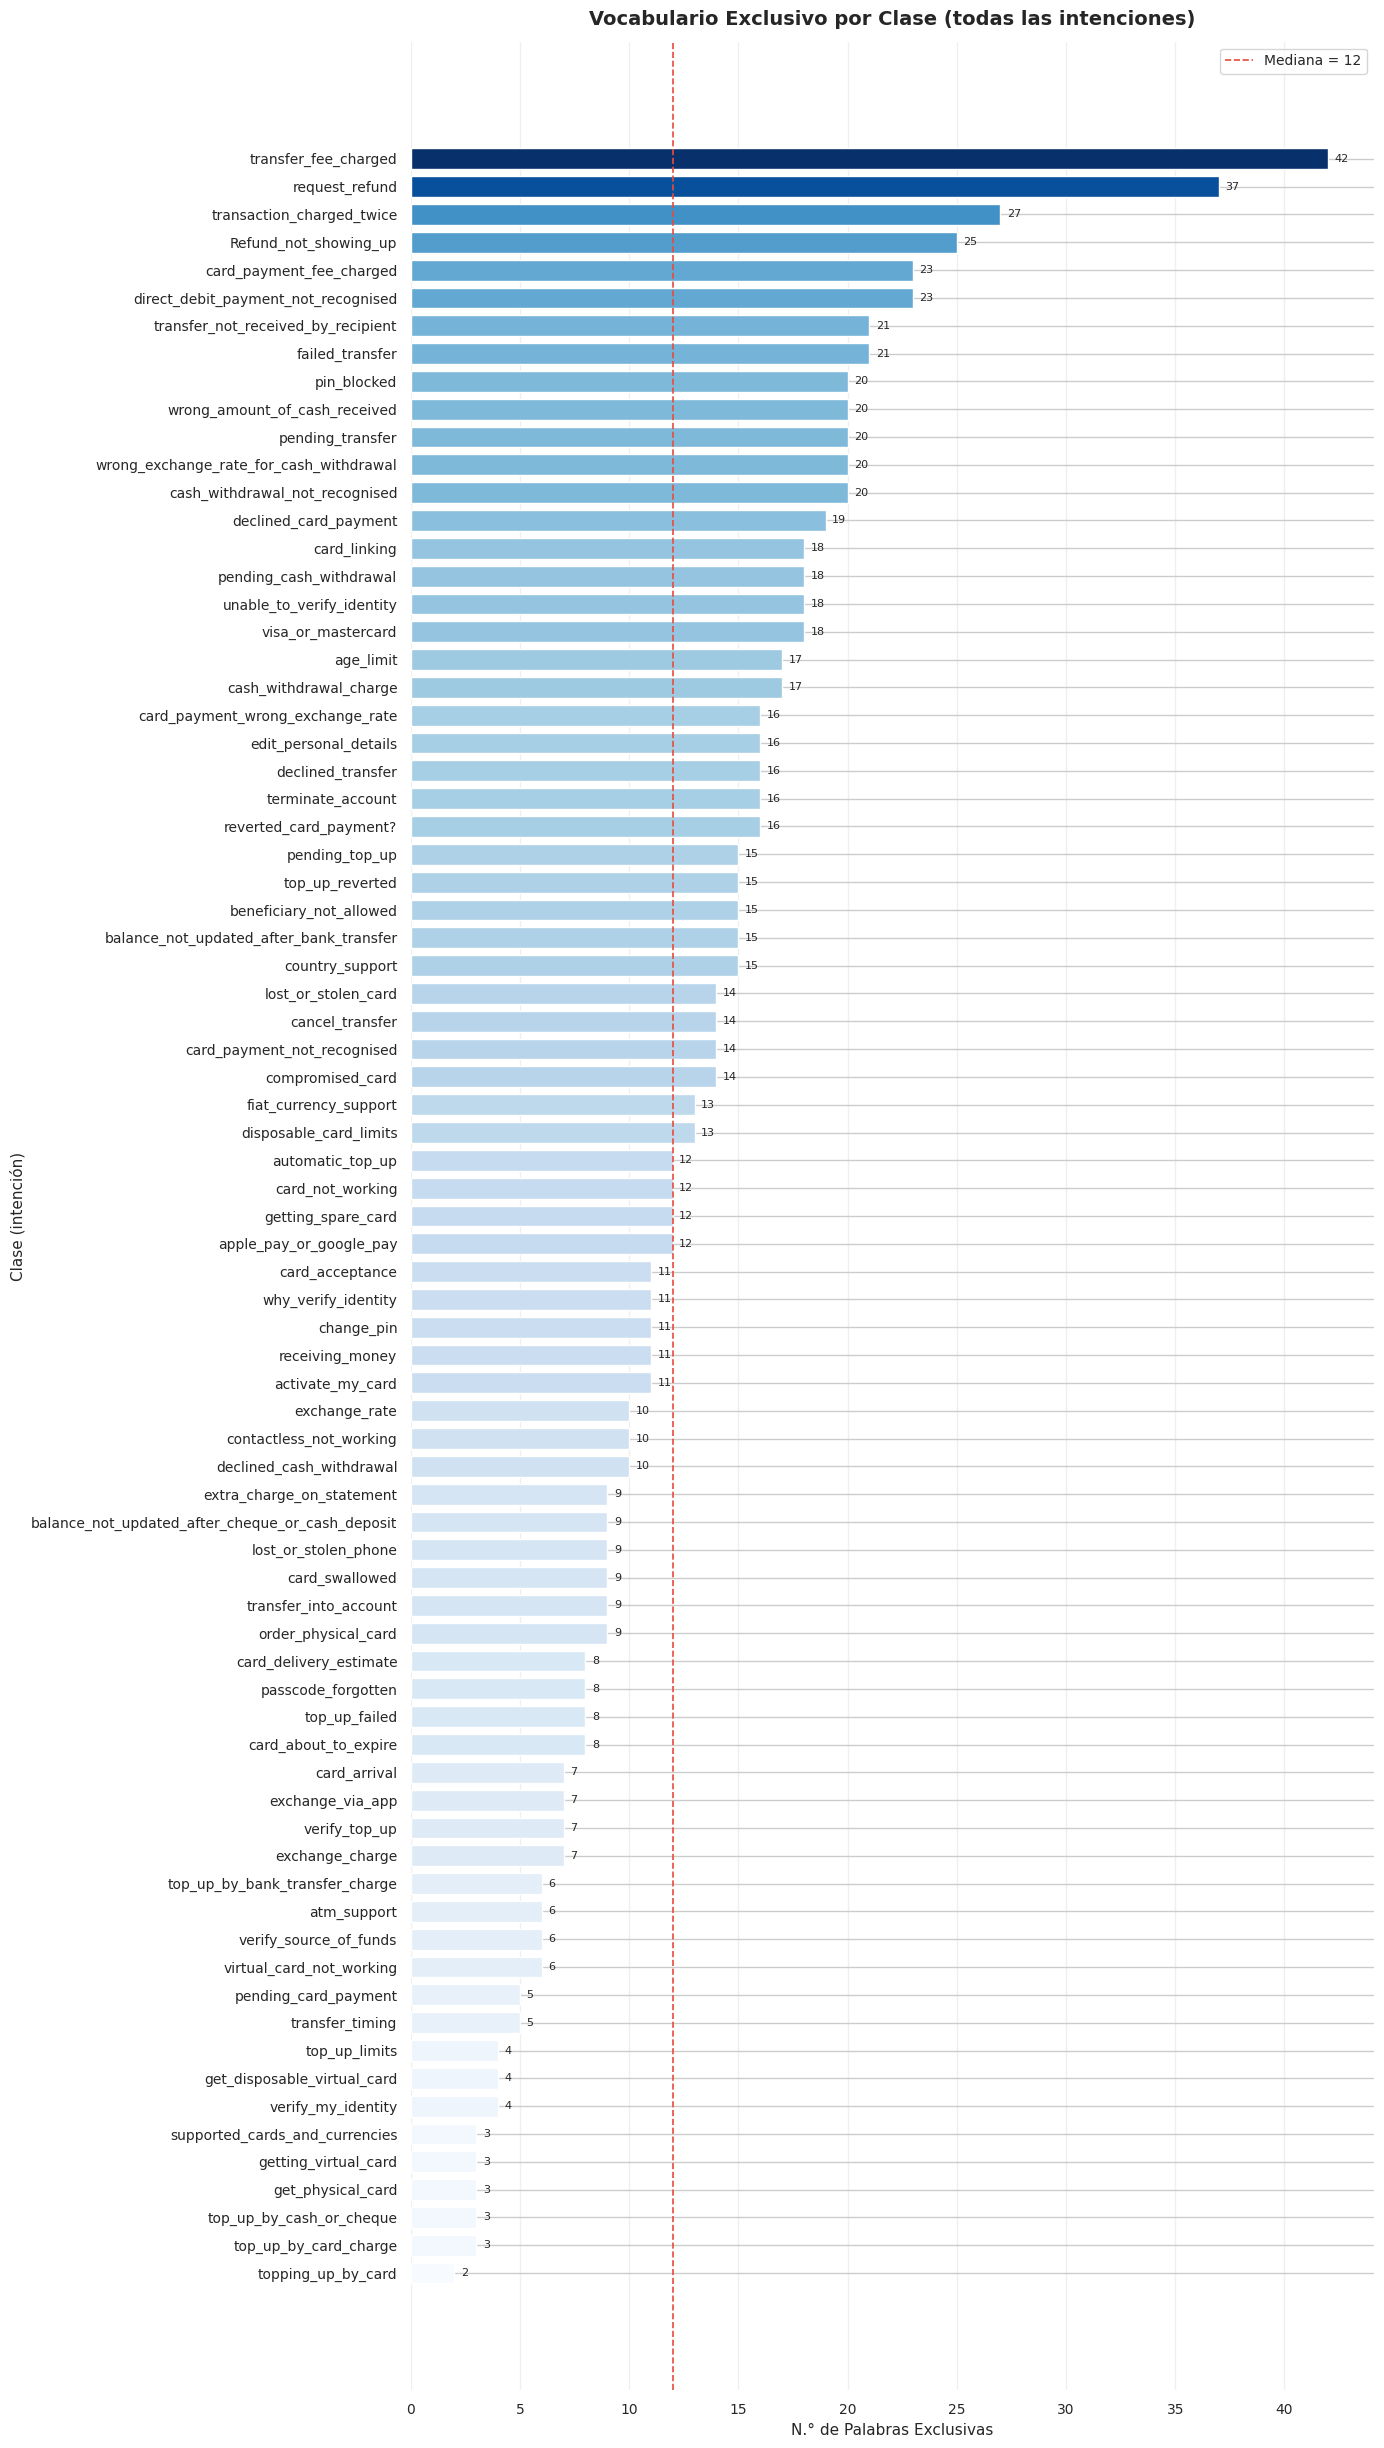


── Muestra de palabras exclusivas (top-10 clases) ──
  [ 42] transfer_fee_charged: ['7000', 'alert', 'alls', 'beach', 'benow', 'bora', 'budget', 'chargged', 'condo', 'crossreference']
  [ 37] request_refund: ['45', 'aggravated', 'begin', 'buyer', 'cancelling', 'chat', 'color', 'competent', 'cry', 'deeply']
  [ 27] transaction_charged_twice: ['attend', 'canada', 'chaged', 'doublecharged', 'duplicated', 'expense', 'fixing', 'fro', 'instore', 'meal']
  [ 25] Refund_not_showing_up: ['accountcould', 'appiled', 'arm', 'assure', 'avail', 'cone', 'creditrefund', 'dress', 'fan', 'frustrated']
  [ 23] card_payment_fee_charged: ['10000', 'additionally', 'advertise', 'clarify', 'feefree', 'forewarn', 'format', 'hell', 'impose', 'instance']
  [ 23] direct_debit_payment_not_recognised: ['authorized', 'boyfriend', 'diret', 'discrepancy', 'disputable', 'fairly', 'largeish', 'legit', 'listing', 'mad']
  [ 21] transfer_not_received_by_recipient: ['completion', 'confusion', 'didint', 'durham', 'friday',

In [109]:
# ─── 1. Construir el vocabulario por clase ───────────────────────────────────
# Usamos text_clean (ya normalizado/lematizado) para mayor coherencia
class_vocab = defaultdict(set)

for _, row in df_clean.iterrows():
    tokens = str(row["text_clean"]).split()
    class_vocab[row["category"]].update(tokens)

# ─── 2. Calcular las clases ──────────────────────────────────────────────────
all_classes = list(class_vocab.keys())

# ─── 3. Vocabulario exclusivo: palabras que sólo aparecen en UNA clase ──────
exclusive_vocab = {}

for cls in all_classes:
    # Unión de vocabularios de TODAS las otras clases
    other_vocab = set().union(
        *[class_vocab[other] for other in all_classes if other != cls]
    )
    exclusive_vocab[cls] = class_vocab[cls] - other_vocab

# ─── 4. Estadísticas resumidas ──────────────────────────────────────────────
exclusive_counts = {
    cls: len(words) for cls, words in exclusive_vocab.items()
}

# Clases con vocabulario exclusivo nulo
zero_exclusive = sum(1 for v in exclusive_counts.values() if v == 0)
n_classes = len(all_classes)
sorted_values = sorted(exclusive_counts.values())
mediana = sorted_values[n_classes // 2]
media = sum(sorted_values) / n_classes

print(f"Total de clases analizadas : {n_classes}")
print(f"Clases CON palabras exclusivas : {n_classes - zero_exclusive} / {n_classes}  "
      f"(es decir, {n_classes - zero_exclusive} intenciones tienen al menos 1 término único)")
print(f"Clases SIN palabras exclusivas : {zero_exclusive} / {n_classes}  "
      f"(todo su léxico es compartido con otras intenciones)")
print(f"Mediana de palabras exclusivas : {mediana}  "
      f"(la mitad de las clases tiene ≤ {mediana} términos únicos)")
print(f"Media   de palabras exclusivas : {media:.1f}")
print(f"Máximo  de palabras exclusivas : {sorted_values[-1]}")
print(f"Mínimo  de palabras exclusivas : {sorted_values[0]}")

# ─── 5. Visualización: TODAS las clases ordenadas de mayor a menor ───────────
sorted_classes = sorted(exclusive_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_classes)

# Altura dinámica: ~0.32 px por clase para que quepan los 77 nombres
fig_height = max(12, len(labels) * 0.32)
fig, ax = plt.subplots(figsize=(14, fig_height))

# Paleta de color proporcional al número de palabras exclusivas
norm = plt.Normalize(vmin=min(counts), vmax=max(counts))
colors = plt.cm.Blues(norm(counts[::-1]))

bars = ax.barh(labels[::-1], counts[::-1], color=colors, edgecolor="white", height=0.75)

# Etiqueta numérica al final de cada barra
for bar, count in zip(bars, counts[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center", ha="left", fontsize=8
    )

# Línea de mediana
ax.axvline(mediana, color="#e74c3c", linestyle="--", linewidth=1.2,
           label=f"Mediana = {mediana}")

ax.set_title(
    "Vocabulario Exclusivo por Clase (todas las intenciones)",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_xlabel("N.° de Palabras Exclusivas", fontsize=11)
ax.set_ylabel("Clase (intención)", fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.legend(fontsize=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# ─── 6. Muestra de palabras exclusivas para las 10 clases con más vocabulario ─
print("\n── Muestra de palabras exclusivas (top-10 clases) ──")
for cls, cnt in sorted_classes[:10]:
    sample = sorted(exclusive_vocab[cls])[:10]
    print(f"  [{cnt:3d}] {cls}: {sample}")

# Etapa 2 — Preprocesamiento del Conjunto de Datos

En esta etapa se transforma el dataset crudo en representaciones numéricas aptas
para los algoritmos de aprendizaje automático.

1. **Preprocesamiento de texto:** limpieza, tokenización y lematización.
2. **Feature Engineering:** creación de variables numéricas derivadas del texto.
3. **División train/test:** separación estratificada del conjunto de datos.
4. **Representaciones vectoriales del lenguaje:** TF-IDF y Embeddings.
5. **Codificación de la variable de salida (`y`):** conversión de etiquetas a enteros.
6. **Balance del conjunto de datos:** análisis del impacto del desbalanceo de clases.

## Preprocesamiento de Texto

Las funciones `clean_text` y `get_wordnet_pos` fueron definidas al inicio del notebook
(sección *Funciones Auxiliares*) y ya fueron aplicadas al cargar el dataset.
La columna `text_clean` contiene el texto normalizado y lematizado que se utiliza
como entrada para las representaciones vectoriales descritas a continuación.

### Feature Engineering: Codificación del Texto

Se preparan **dos representaciones** distintas de los datos independientes (`X`),
cada una más adecuada para distintos tipos de modelo:

| Representación | Descripción | Modelos que la usan |
|----------------|-------------|---------------------|
| **TF-IDF** | Matriz dispersa clásica basada en frecuencia de términos (sobre `text_clean`, ya normalizado y lematizado). | Regresión Logística, SVM |
| **Embeddings (SBERT)** | Representación densa semántica con *Sentence Transformers* (sobre el texto original). | XGBoost, MLP |

## División del Conjunto de Datos

Se realiza una **división estratificada** (80 % entrenamiento / 20 % prueba) para garantizar
que la proporción de cada clase se mantenga en ambos conjuntos.

La estratificación es especialmente importante en este dataset dado el desbalanceo
moderado que presentan algunas categorías.

> La división se realiza **antes** de ajustar cualquier
> vectorizador o transformador, evitando así *data leakage* (filtración de información
> del conjunto de prueba al entrenamiento).

In [110]:
# Definimos variables independientes (X) y target (y)
# Unimos df y df_clean (con text_clean) para armar X'
X = pd.DataFrame({
    'text_clean': df_clean['text_clean'],
    'text': df['text'],
})
y = df['category']

# 2. Hacemos el split estratificado (clave para datasets de clasificación con muchas categorías)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensiones de Train: {X_train.shape[0]} muestras")
print(f"Dimensiones de Test : {X_test.shape[0]} muestras")


Dimensiones de Train: 10466 muestras
Dimensiones de Test : 2617 muestras


## Representaciones Vectoriales del Lenguaje

Se generan las dos representaciones de texto descritas anteriormente.
En ambos casos los transformadores se **ajustan únicamente sobre el conjunto de entrenamiento**
y se aplican tanto a train como a test para evitar *data leakage*.

### Vectorizador TF-IDF
- **`max_features=5000`**: se retienen como máximo las 5 000 palabras más frecuentes del vocabulario.
- Entrada: `text_clean` (texto normalizado y lematizado).

### Sentence Transformers (Embeddings Semánticos)
- Modelo: `all-MiniLM-L6-v2` (rápido y ligero, embeddings de 384 dimensiones).
- Se usa el **texto original** (no el limpiado) para preservar el contexto semántico.

In [111]:
# --- Opción 1: TF-IDF ---
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf_train = tfidf.fit_transform(X_train['text_clean'])   # fit solo en train
X_tfidf_test  = tfidf.transform(X_test['text_clean'])        # solo transform en test
print(f"1. Shape de X_tfidf_train: {X_tfidf_train.shape} (Matriz Dispersa)")
print(f"   Shape de X_tfidf_test : {X_tfidf_test.shape} (Matriz Dispersa)\n")

# Opción 2: Sentence Embeddings
print("Generando Embeddings...")
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

X_embs_train = model_sbert.encode(X_train['text'].tolist(), show_progress_bar=True)
X_embs_test  = model_sbert.encode(X_test['text'].tolist(), show_progress_bar=True)
print(f"3. Shape de X_embs_train: {X_embs_train.shape} (Matriz Densa)")
print(f"   Shape de X_embs_test : {X_embs_test.shape} (Matriz Densa)\n")

1. Shape de X_tfidf_train: (10466, 1800) (Matriz Dispersa)
   Shape de X_tfidf_test : (2617, 1800) (Matriz Dispersa)

Generando Embeddings...


Batches: 100%|██████████| 82/82 [00:04<00:00, 17.92it/s]

3. Shape de X_embs_train: (10466, 384) (Matriz Densa)
   Shape de X_embs_test : (2617, 384) (Matriz Densa)



## Procesamiento de la Variable de Salida

Las etiquetas de clase (`category`) son cadenas de texto que deben convertirse a
enteros para ser consumidas por los modelos de aprendizaje automático.

Se utiliza `LabelEncoder` de scikit-learn:
- **`fit`** únicamente sobre el conjunto de entrenamiento.
- **`transform`** aplicado tanto a train como a test.

Esto asigna un identificador numérico único (0–76) a cada una de las 77 clases.

In [112]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Guardamos los nombres de clase en orden para usarlos en métricas de evaluación
# (classification_report, matriz de confusión, etc.)
class_names = encoder.classes_  # array de 77 nombres en orden

print(f"Dimensiones de y_train_encoded: {y_train_encoded.shape}")
print(f"Dimensiones de y_test_encoded : {y_test_encoded.shape}")

Dimensiones de y_train_encoded: (10466,)
Dimensiones de y_test_encoded : (2617,)


In [113]:
class_names[:6]

array(['Refund_not_showing_up', 'activate_my_card', 'age_limit',
       'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up'],
      dtype=object)

# Etapa 3 — Entrenamiento y Evaluación de Modelos

En esta etapa se entrenan y evalúan múltiples modelos de clasificación, siguiendo las
pautas:

- **División del conjunto:** train (80 %) / test (20 %), ya realizada en la Etapa 2.
- **Validación:** la búsqueda de hiperparámetros se hace con **validación cruzada estratificada**
  (`GridSearchCV` / `RandomizedSearchCV`) **sobre el conjunto de entrenamiento**. El conjunto de
  test se reserva exclusivamente para la **evaluación final** de cada modelo (una sola vez),
  evitando así el sobreajuste a los datos de prueba.
- **Métricas de evaluación:** se reportan *accuracy*, *F1-score macro*, *F1-score weighted*
  y *matriz de confusión* para comparar los modelos de forma homogénea.
- **Desbalanceo:** todos los modelos compensan el desbalanceo de clases (pesos `balanced`).

### Modelos a entrenar
| Modelo | Representación | Justificación |
|--------|----------------|---------------|
| **Regresión Logística** | TF-IDF | Baseline lineal sólido para clasificación de texto. |
| **XGBoost** | Embeddings | Captura interacciones no lineales; compensa el desbalanceo con pesos por muestra. |
| **SVM lineal** | TF-IDF | Muy efectivo en espacios dispersos de alta dimensión. |
| **MLP (PyTorch)** | Embeddings | Captura patrones no lineales; ideal para embeddings densos. |

In [114]:
# ─── Utilidades de evaluación comunes a todos los modelos ────────────────────
# Acumulamos las métricas de cada modelo para la comparativa final.
# IMPORTANTE: trabajamos siempre con etiquetas codificadas (y_*_encoded) para que
# la comparación sea homogénea entre modelos.
resultados = {}

# Validación cruzada estratificada reutilizada por GridSearchCV/RandomizedSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


def evaluar_modelo(nombre, y_true_enc, y_pred_enc,
                    mostrar_cm=False, mostrar_reporte=True):
    """Evalúa un modelo sobre el conjunto de TEST y guarda sus métricas en `resultados`.

    Args:
        nombre       : identificador del modelo (clave en `resultados`).
        y_true_enc   : etiquetas verdaderas codificadas (enteros del LabelEncoder).
        y_pred_enc   : predicciones del modelo, también codificadas.
        mostrar_cm   : si True, dibuja la matriz de confusión 77×77.
        mostrar_reporte: si True, imprime el classification_report completo.
    """
    acc = accuracy_score(y_true_enc, y_pred_enc)
    f1_macro   = f1_score(y_true_enc, y_pred_enc, average='macro',    zero_division=0)
    f1_weighted = f1_score(y_true_enc, y_pred_enc, average='weighted', zero_division=0)

    resultados[nombre] = {
        'Accuracy'   : acc,
        'F1 macro'   : f1_macro,
        'F1 weighted': f1_weighted,
    }

    print(f"=== {nombre} ===")
    print(f"Accuracy    : {acc:.4f}")
    print(f"F1 macro    : {f1_macro:.4f}")
    print(f"F1 weighted : {f1_weighted:.4f}")

    if mostrar_reporte:
        print("\n" + classification_report(
            y_true_enc, y_pred_enc, target_names=class_names, zero_division=0
        ))

    if mostrar_cm:
        cm = confusion_matrix(y_true_enc, y_pred_enc)
        fig, ax = plt.subplots(figsize=(16, 14))
        sns.heatmap(cm, cmap="Blues", cbar=True,
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(f"Matriz de Confusión — {nombre}", fontsize=14, fontweight="bold")
        ax.set_xlabel("Predicho")
        ax.set_ylabel("Real")
        ax.tick_params(axis="x", labelsize=6, rotation=90)
        ax.tick_params(axis="y", labelsize=6)
        plt.tight_layout()
        plt.show()

    return resultados[nombre]

## 3.1 Regresión Logística

Se prueban dos variantes de Regresión Logística:
- **3.1.1** con vectorización TF-IDF (texto lematizado).
- **3.1.2** con embeddings semánticos SBERT (`all-MiniLM-L6-v2`), usando el texto original sin lematizar para preservar el contexto semántico que el modelo pre-entrenado necesita.

### 3.1.1 RL con TF-IDF

In [115]:
# ── 3.1.1  Regresión Logística + TF-IDF ────────────────────────────────────────
# GridSearchCV con validación cruzada estratificada.
# El conjunto de TEST queda completamente reservado para la evaluación final.

from sklearn.model_selection import StratifiedKFold

log_reg = LogisticRegression(
    max_iter=1000,             # margen amplio para garantizar convergencia en multiclase
    n_jobs=-1,                 # paralelismo dentro del estimador
    random_state=42,
)

param_grid_lr = {
    'C':            [0.01, 0.1, 1, 5, 10, 100],   # inverso de la regularización
    'solver':       ['lbfgs', 'saga'],              # algoritmos de optimización
    'class_weight': [None, 'balanced'],             # compensación de desbalanceo
}

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    log_reg,
    param_grid_lr,
    scoring='f1_macro',        # métrica: F1 macro trata igual a todas las clases
    cv=cv_stratified,          # 5-fold estratificado
    n_jobs=-1,                 # paralelizar combinaciones
    verbose=1,
    refit=True,                # re-entrenar el mejor modelo con todo X_train
    return_train_score=True,   # útil para detectar overfitting
)

total_combos = (len(param_grid_lr['C']) * len(param_grid_lr['solver'])
                * len(param_grid_lr['class_weight']))
print(f"Combinaciones a evaluar: {total_combos} x 5 folds = {total_combos * 5} entrenamientos")

grid_lr.fit(X_tfidf_train, y_train_encoded)

print(f"Mejores hiperparámetros (LR+TF-IDF): {grid_lr.best_params_}")
print(f"Mejor F1-macro en CV               : {grid_lr.best_score_:.4f}\n")

# Evaluación final sobre el TEST (una sola vez)
best_lr_tfidf = grid_lr.best_estimator_
y_pred_lr_tfidf = best_lr_tfidf.predict(X_tfidf_test)
evaluar_modelo("Regresión Logística (TF-IDF)", y_test_encoded, y_pred_lr_tfidf)

Combinaciones a evaluar: 24 x 5 folds = 120 entrenamientos
Fitting 5 folds for each of 24 candidates, totalling 120 fits


Mejores hiperparámetros (LR+TF-IDF): {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Mejor F1-macro en CV               : 0.8682

=== Regresión Logística (TF-IDF) ===
Accuracy    : 0.8831
F1 macro    : 0.8814
F1 weighted : 0.8832

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.97      0.99        40
                                activate_my_card       1.00      0.90      0.95        40
                                       age_limit       0.97      1.00      0.98        30
                         apple_pay_or_google_pay       1.00      1.00      1.00        33
                                     atm_support       0.92      0.88      0.90        25
                                automatic_top_up       1.00      0.88      0.94        33
         balance_not_updated_after_bank_transfer       0.78      0.83      0.80        42
balance_not_updated_after_cheque_or_cas

{'Accuracy': 0.8830722200993504,
 'F1 macro': 0.881440862733119,
 'F1 weighted': 0.8831727760524496}

### 3.1.2 RL con SBERT (Embeddings)

**¿Por qué usar el texto original (sin lematizar)?**  
SBERT (`all-MiniLM-L6-v2`) es un modelo de lenguaje pre-entrenado que entiende el contexto
semántico completo de la oración. La función `clean_text()` que usamos para TF-IDF
elimina stopwords y lematiza, destruyendo ese contexto. Por eso aquí usamos `df['text']`
(texto original) en lugar de `df['text_clean']`.

Los embeddings SBERT (384 dimensiones, densos) capturan sinónimos y paráfrasis:  
"¿Cómo bloqueo mi tarjeta?" ≈ "Necesito cancelar mi tarjeta de crédito".

In [116]:
# ── 3.1.2  Regresión Logística + Embeddings SBERT ───────────────────────────────
# IMPORTANTE: se usan los embeddings X_embs_train / X_embs_test ya generados
# en el bloque anterior (Sección 3 - bloque de embeddings con SentenceTransformer).
# Esos embeddings se calcularon sobre df['text'] (texto ORIGINAL, no lematizado).

log_reg_emb = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    random_state=42,
)

# Mismo espacio de búsqueda que en 3.1.1 para comparación directa
param_grid_lr_emb = {
    'C':            [0.01, 0.1, 1, 5, 10, 100],
    'solver':       ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced'],
}

grid_lr_emb = GridSearchCV(
    log_reg_emb,
    param_grid_lr_emb,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
)

print('Iniciando GridSearchCV con embeddings SBERT...')
grid_lr_emb.fit(X_embs_train, y_train_encoded)

print(f"Mejores hiperparámetros (LR+SBERT): {grid_lr_emb.best_params_}")
print(f"Mejor F1-macro en CV              : {grid_lr_emb.best_score_:.4f}\n")

# Evaluación final sobre el TEST (una sola vez)
best_lr_emb = grid_lr_emb.best_estimator_
y_pred_lr_emb = best_lr_emb.predict(X_embs_test)
evaluar_modelo("Regresión Logística (SBERT)", y_test_encoded, y_pred_lr_emb)

# ── Comparación rápida TF-IDF vs SBERT ──────────────────────────────────────
from sklearn.metrics import f1_score, accuracy_score

print('=' * 60)
print('COMPARATIVA: RL + TF-IDF  vs  RL + SBERT (Embeddings)')
print('=' * 60)
print(f"{'Método':<35} {'F1-macro CV':>12} {'F1-macro TEST':>14}")
print('-' * 60)
print(f"{'RL + TF-IDF':<35} {grid_lr.best_score_:>12.4f} ",
      f"{f1_score(y_test_encoded, y_pred_lr_tfidf, average='macro'):>14.4f}")
print(f"{'RL + SBERT (Embeddings)':<35} {grid_lr_emb.best_score_:>12.4f} ",
      f"{f1_score(y_test_encoded, y_pred_lr_emb, average='macro'):>14.4f}")

Iniciando GridSearchCV con embeddings SBERT...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros (LR+SBERT): {'C': 10, 'class_weight': None, 'solver': 'saga'}
Mejor F1-macro en CV              : 0.9279

=== Regresión Logística (SBERT) ===
Accuracy    : 0.9278
F1 macro    : 0.9292
F1 weighted : 0.9280

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       1.00      0.93      0.96        40
                                activate_my_card       1.00      0.95      0.97        40
                                       age_limit       1.00      1.00      1.00        30
                         apple_pay_or_google_pay       1.00      1.00      1.00        33
                                     atm_support       1.00      0.96      0.98        25
                                automatic_top_up       1.00      0.88      0.94        33
         balance_not_updated_a

## 3.2 XGBoost (Extreme Gradient Boosting)

In [117]:
import xgboost as xgb

# XGBoost sobre embeddings densos, con búsqueda aleatoria de hiperparámetros (CV estratificada).
xgb_model = xgb.XGBClassifier(
    n_jobs=-1,            # usar todos los núcleos del procesador
    random_state=42,
    tree_method='hist',  # entrenamiento más rápido
)

param_dist_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0],
}

# Pesos por muestra para compensar el desbalanceo de clases
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

rand_xgb = RandomizedSearchCV(
    xgb_model, param_dist_xgb,
    n_iter=5, scoring='f1_macro', cv=cv, n_jobs=-1,
    random_state=42, verbose=1,
)
rand_xgb.fit(X_embs_train, y_train_encoded, sample_weight=sample_weight)

print(f"Mejores hiperparámetros (XGBoost): {rand_xgb.best_params_}")
print(f"Mejor F1-macro en CV             : {rand_xgb.best_score_:.4f}\n")

# Evaluación final sobre el TEST (una sola vez)
best_xgb = rand_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_embs_test)
evaluar_modelo("XGBoost (Embeddings)", y_test_encoded, y_pred_xgb)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejores hiperparámetros (XGBoost): {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
Mejor F1-macro en CV             : 0.8916

=== XGBoost (Embeddings) ===
Accuracy    : 0.8999
F1 macro    : 0.9005
F1 weighted : 0.8998

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.95      0.95      0.95        40
                                activate_my_card       0.97      0.93      0.95        40
                                       age_limit       1.00      1.00      1.00        30
                         apple_pay_or_google_pay       0.94      1.00      0.97        33
                                     atm_support       0.96      0.92      0.94        25
                                automatic_top_up       0.93      0.79      0.85        33
         balance_not_updated_after_bank_transfer       0.85 

{'Accuracy': 0.899885364921666,
 'F1 macro': 0.9005130816463679,
 'F1 weighted': 0.8998125676266515}

## 3.3 SVM (Support Vector Machine) o SVC (Support Vector Classifier)

In [118]:
# SVM lineal sobre TF-IDF. LinearSVC escala mucho mejor que SVC(kernel='rbf')
# en espacios dispersos de alta dimensión como TF-IDF.
svm_model = LinearSVC(
    class_weight='balanced',   # compensa el desbalanceo de clases
    random_state=42,
    max_iter=5000,
)

param_grid_svm = {
    'C': [0.5, 1, 5],
}

grid_svm = GridSearchCV(
    svm_model, param_grid_svm,
    scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1,
)
grid_svm.fit(X_tfidf_train, y_train_encoded)

print(f"Mejores hiperparámetros (SVM): {grid_svm.best_params_}")
print(f"Mejor F1-macro en CV         : {grid_svm.best_score_:.4f}\n")

# Evaluación final sobre el TEST (una sola vez)
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_tfidf_test)
evaluar_modelo("SVM lineal (TF-IDF)", y_test_encoded, y_pred_svm)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Mejores hiperparámetros (SVM): {'C': 1}
Mejor F1-macro en CV         : 0.8509

=== SVM lineal (TF-IDF) ===
Accuracy    : 0.8777
F1 macro    : 0.8748
F1 weighted : 0.8775

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.97      0.97        40
                                activate_my_card       1.00      0.90      0.95        40
                                       age_limit       0.94      1.00      0.97        30
                         apple_pay_or_google_pay       1.00      1.00      1.00        33
                                     atm_support       0.92      0.88      0.90        25
                                automatic_top_up       1.00      0.91      0.95        33
         balance_not_updated_after_bank_transfer       0.86      0.76      0.81        42
balance_not_updated_after_cheque_or_cash_deposit 

{'Accuracy': 0.8777225831104318,
 'F1 macro': 0.8747991568625748,
 'F1 weighted': 0.8775346514210847}

## 3.4 MLP (Perceptrón Multicapa con PyTorch)

In [119]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# --- Conjunto de validación (separado del TRAIN) para early stopping ---
# El TEST NO se usa durante el entrenamiento; sólo en la evaluación final.
X_tr, X_val, y_tr, y_val = train_test_split(
    np.array(X_embs_train), y_train_encoded,
    test_size=0.15, random_state=42, stratify=y_train_encoded
)

X_tensor_train = torch.tensor(X_tr, dtype=torch.float32)
y_tensor_train = torch.tensor(y_tr, dtype=torch.long)
X_tensor_val   = torch.tensor(X_val, dtype=torch.float32)
y_tensor_val   = torch.tensor(y_val, dtype=torch.long)

# Crear DataLoader para iterar en lotes (batches)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Definición de la Red Neuronal
class IntentMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(IntentMLP, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),            # Apaga el 30% de las neuronas para evitar overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes) # Capa final de salida (77 neuronas)
        )

    def forward(self, x):
        return self.red(x)

# Inicializar modelo
input_dim = X_embs_train.shape[1]      # Ej. 384 (SBERT)
num_classes = len(class_names)         # 77 clases
mlp_model = IntentMLP(input_dim, num_classes)

# 3. Función de pérdida (con pesos de clase para el desbalanceo) y optimizador
class_weights = compute_class_weight(
    'balanced', classes=np.arange(num_classes), y=y_train_encoded
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# 4. Bucle de Entrenamiento con Early Stopping sobre la validación
epochs = 50
patience = 5
best_val_loss = float('inf')
epochs_sin_mejora = 0
best_state = None

for epoch in range(epochs):
    mlp_model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()             # Limpiar gradientes
        outputs = mlp_model(batch_X)      # Paso hacia adelante (forward)
        loss = criterion(outputs, batch_y)# Calcular error
        loss.backward()                   # Retropropagación (backward)
        optimizer.step()                  # Actualizar pesos
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    # Pérdida de validación (modo eval: apaga Dropout)
    mlp_model.eval()
    with torch.no_grad():
        val_loss = criterion(mlp_model(X_tensor_val), y_tensor_val).item()

    print(f"Época {epoch+1:02d}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    # Early stopping: guardamos los mejores pesos según la validación
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
        epochs_sin_mejora = 0
    else:
        epochs_sin_mejora += 1
        if epochs_sin_mejora >= patience:
            print(f"Early stopping en la época {epoch+1} (sin mejora en {patience} épocas).")
            break

# Restaurar los mejores pesos encontrados
if best_state is not None:
    mlp_model.load_state_dict(best_state)

# 5. Predicción y evaluación final sobre el TEST
mlp_model.eval() # Modo evaluación (apaga el Dropout)
with torch.no_grad(): # Desactiva el cálculo de gradientes
    X_tensor_test = torch.tensor(np.array(X_embs_test), dtype=torch.float32)
    test_outputs = mlp_model(X_tensor_test)
    y_pred_mlp = torch.argmax(test_outputs, dim=1).numpy()  # clase con mayor logit

evaluar_modelo("MLP (Embeddings)", y_test_encoded, y_pred_mlp)

Época 01/50 | Train: 2.8277 | Val: 1.2312
Época 02/50 | Train: 1.1265 | Val: 0.6718
Época 03/50 | Train: 0.8039 | Val: 0.5335
Época 04/50 | Train: 0.6545 | Val: 0.4636
Época 05/50 | Train: 0.5712 | Val: 0.4381
Época 06/50 | Train: 0.5129 | Val: 0.3903
Época 07/50 | Train: 0.4658 | Val: 0.3902
Época 08/50 | Train: 0.4296 | Val: 0.3827
Época 09/50 | Train: 0.3964 | Val: 0.3592
Época 10/50 | Train: 0.3693 | Val: 0.3590
Época 11/50 | Train: 0.3530 | Val: 0.3547
Época 12/50 | Train: 0.3239 | Val: 0.3365
Época 13/50 | Train: 0.3188 | Val: 0.3458
Época 14/50 | Train: 0.3058 | Val: 0.3377
Época 15/50 | Train: 0.2888 | Val: 0.3326
Época 16/50 | Train: 0.2736 | Val: 0.3225
Época 17/50 | Train: 0.2469 | Val: 0.3265
Época 18/50 | Train: 0.2539 | Val: 0.3264
Época 19/50 | Train: 0.2384 | Val: 0.3341
Época 20/50 | Train: 0.2281 | Val: 0.3180
Época 21/50 | Train: 0.2073 | Val: 0.3208
Época 22/50 | Train: 0.2080 | Val: 0.3245
Época 23/50 | Train: 0.2064 | Val: 0.3203
Época 24/50 | Train: 0.1936 | Val:

{'Accuracy': 0.9117309896828429,
 'F1 macro': 0.9120179458432212,
 'F1 weighted': 0.9120260331965578}

## 3.5 Comparativa de Modelos

Se reúnen las métricas obtenidas por cada modelo sobre el conjunto de **test** (accuracy, F1-macro y F1-weighted) en una tabla y un gráfico comparativo. El F1-macro es especialmente relevante aquí porque, al promediar por clase sin ponderar por frecuencia, refleja mejor el rendimiento sobre las **clases minoritarias** en este dataset desbalanceado.

=== Comparativa de modelos (métricas sobre el TEST) ===
                              Accuracy  F1 macro  F1 weighted
Regresión Logística (SBERT)     0.9278    0.9292       0.9280
MLP (Embeddings)                0.9117    0.9120       0.9120
XGBoost (Embeddings)            0.8999    0.9005       0.8998
Regresión Logística (TF-IDF)    0.8831    0.8814       0.8832
SVM lineal (TF-IDF)             0.8777    0.8748       0.8775


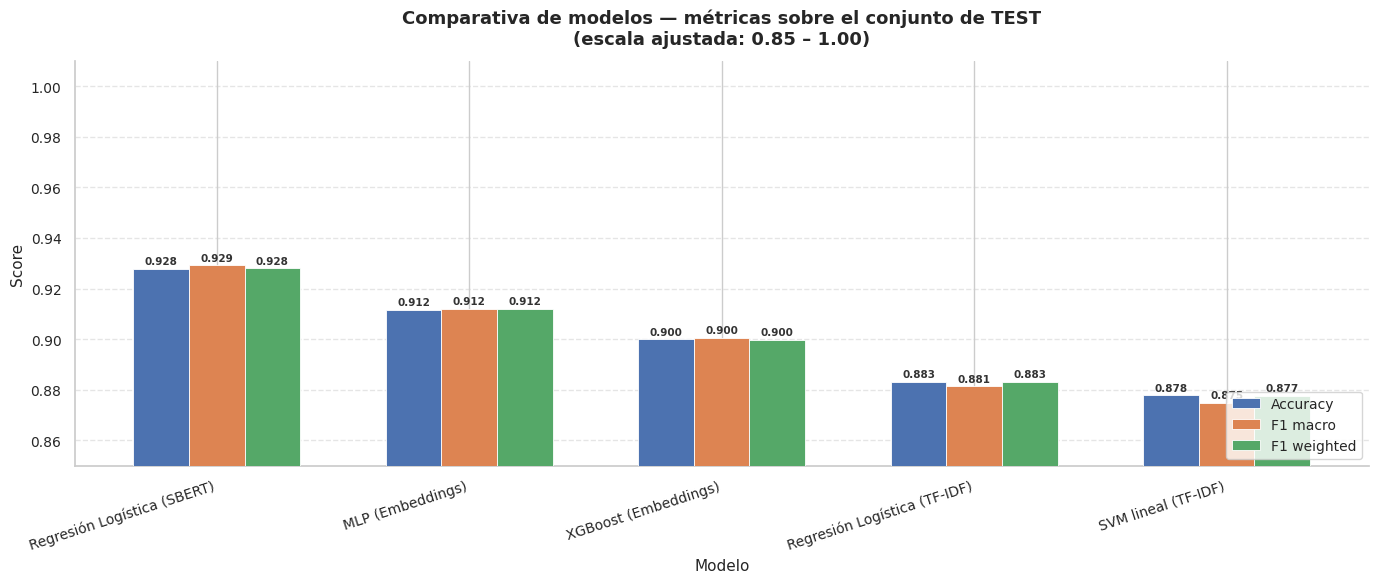

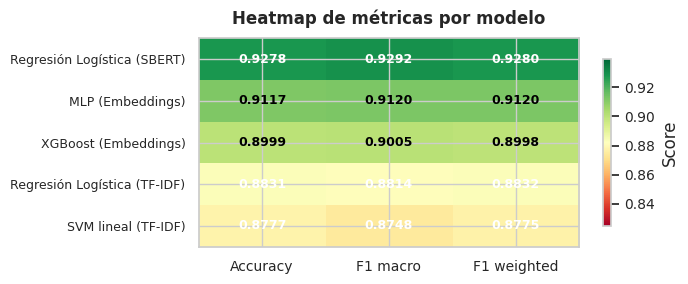

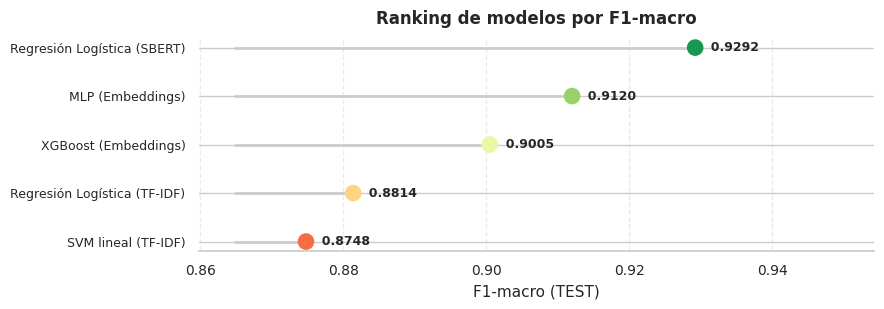


Mejor modelo por F1-macro: Regresión Logística (SBERT) (F1-macro = 0.9292)


In [120]:
df_resultados = (pd.DataFrame(resultados).T
                 .sort_values('F1 macro', ascending=False)
                 .round(4))

print("=== Comparativa de modelos (métricas sobre el TEST) ===")
print(df_resultados.to_string())

# Paleta de colores
METRICS   = ['Accuracy', 'F1 macro', 'F1 weighted']
COLORS    = ['#4C72B0', '#DD8452', '#55A868']   # azul, naranja, verde
n_models  = len(df_resultados)
n_metrics = len(METRICS)
x         = np.arange(n_models)
bar_w     = 0.22

# Figura 1: Barras agrupadas con valores, escala ajustada
fig, ax = plt.subplots(figsize=(14, 6))

# Rango dinámico: 2 pp por debajo del mínimo, techo en 1.0
min_val  = df_resultados[METRICS].values.min()
y_bottom = max(0.0, round(min_val - 0.02, 2))

for k, (metric, color) in enumerate(zip(METRICS, COLORS)):
    offsets = x + (k - 1) * bar_w
    values  = df_resultados[metric].values
    bars    = ax.bar(offsets, values - y_bottom,
                     width=bar_w, bottom=y_bottom,
                     color=color, edgecolor='white', linewidth=0.6,
                     label=metric, zorder=3)
    # Etiqueta en cada barra
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_bottom + bar.get_height() + 0.001,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold',
            color='#333333'
        )

ax.set_xticks(x)
ax.set_xticklabels(df_resultados.index, rotation=18, ha='right', fontsize=10)
ax.set_ylim(y_bottom, 1.01)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.set_ylabel("Score", fontsize=11)
ax.set_xlabel("Modelo", fontsize=11)
ax.set_title("Comparativa de modelos — métricas sobre el conjunto de TEST\n"
             f"(escala ajustada: {y_bottom:.2f} – 1.00)",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Figura 2: Heatmap de métricas
fig2, ax2 = plt.subplots(figsize=(7, max(3, n_models * 0.55)))

data_heat = df_resultados[METRICS].values
im = ax2.imshow(data_heat, cmap='RdYlGn', aspect='auto',
                vmin=max(0, data_heat.min() - 0.05),
                vmax=min(1, data_heat.max() + 0.01))

ax2.set_xticks(range(n_metrics))
ax2.set_xticklabels(METRICS, fontsize=10)
ax2.set_yticks(range(n_models))
ax2.set_yticklabels(df_resultados.index, fontsize=9)

# Valor en cada celda
for i in range(n_models):
    for j in range(n_metrics):
        val = data_heat[i, j]
        color_txt = 'black' if 0.35 < (val - data_heat.min()) / ((data_heat.max() - data_heat.min()) + 1e-9) < 0.85 else 'white'
        ax2.text(j, i, f'{val:.4f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color=color_txt)

plt.colorbar(im, ax=ax2, shrink=0.8, label='Score')
ax2.set_title("Heatmap de métricas por modelo", fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

# Figura 3: Ranking por F1-macro (lollipop chart)
fig3, ax3 = plt.subplots(figsize=(9, max(3, n_models * 0.65)))

df_rank = df_resultados.sort_values('F1 macro')  # ascendente → mejor al final
colors_rank = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(df_rank))
)

ax3.hlines(y=range(len(df_rank)), xmin=df_rank['F1 macro'].min() - 0.01,
           xmax=df_rank['F1 macro'], colors='#cccccc', linewidth=2, zorder=1)
ax3.scatter(df_rank['F1 macro'], range(len(df_rank)),
            color=colors_rank, s=120, zorder=2)

for i, (modelo, row) in enumerate(df_rank.iterrows()):
    ax3.text(row['F1 macro'] + 0.001, i, f"  {row['F1 macro']:.4f}",
             va='center', fontsize=9, fontweight='bold')

ax3.set_yticks(range(len(df_rank)))
ax3.set_yticklabels(df_rank.index, fontsize=9)
ax3.set_xlabel("F1-macro (TEST)", fontsize=11)
ax3.set_title("Ranking de modelos por F1-macro", fontsize=12, fontweight='bold', pad=10)
ax3.grid(axis='x', linestyle='--', alpha=0.4)
ax3.spines[['top', 'right', 'left']].set_visible(False)
x_min = df_rank['F1 macro'].min() - 0.015
x_max = df_rank['F1 macro'].max() + 0.025
ax3.set_xlim(x_min, x_max)
plt.tight_layout()
plt.show()

# Conclusión
mejor = df_resultados['F1 macro'].idxmax()
print(f"\nMejor modelo por F1-macro: {mejor} "
      f"(F1-macro = {df_resultados.loc[mejor, 'F1 macro']:.4f})")